# モーメント編集データで学習したモデルの評価

(9000, 7)
method
conrad               1500
fourth_order_gram    1500
gaussian             1500
ics                  1500
third_order_gram     1500
truncated_normal     1500
Name: step, dtype: int64


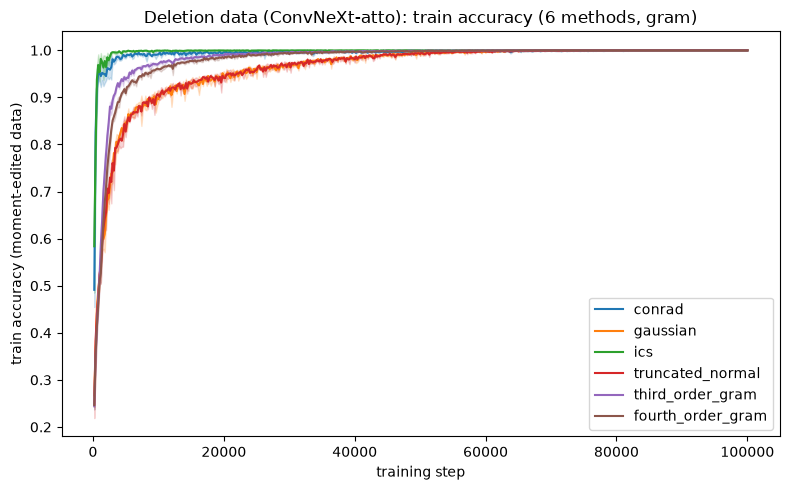

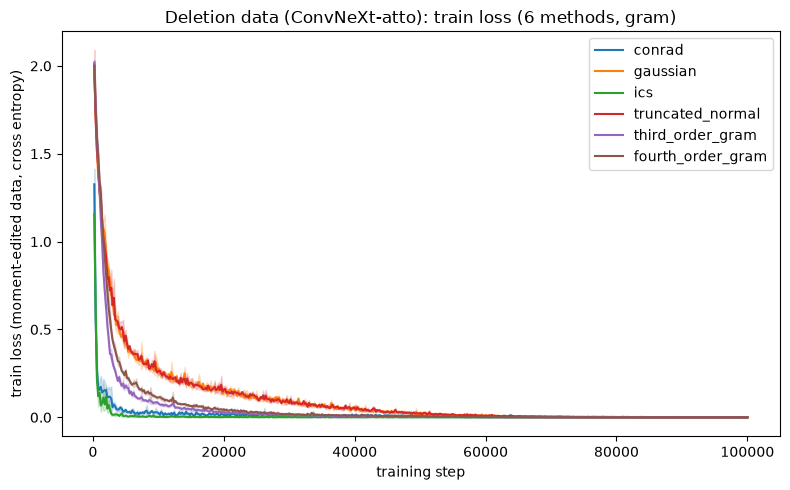

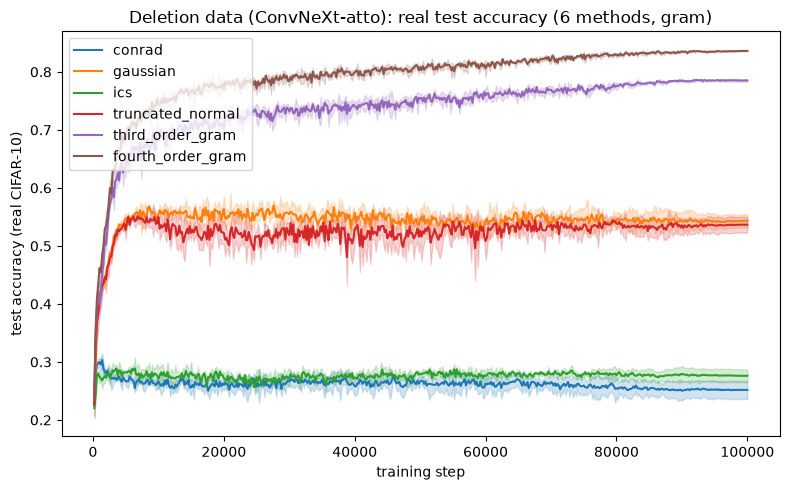

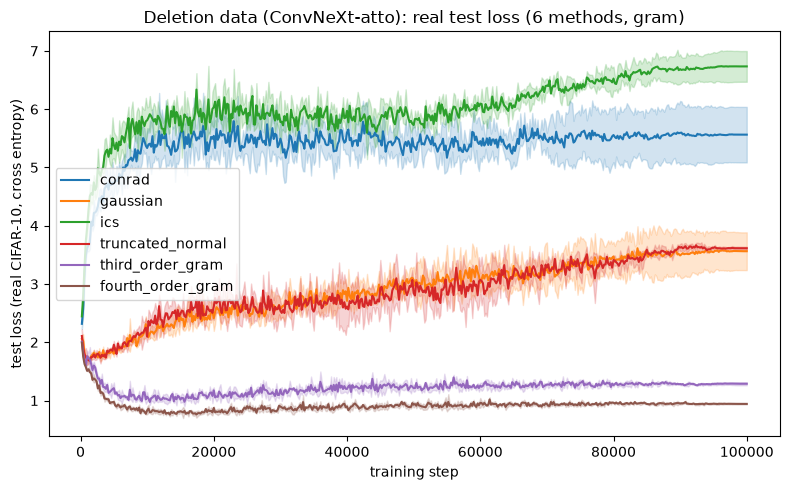

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ── データ読み込み: 既存4手法 + third_order_gram + fourth_order_gram ──
records = []

# 既存4手法 (conrad/gaussian/ics/truncated_normal)
for fname in [
    "/home/nakano/server/llc_results_dense/deletion_vision_full_curve_gpu2.jsonl",
    "/home/nakano/server/llc_results_dense/deletion_vision_full_curve_gpu3.jsonl",
]:
    with open(fname) as f:
        for line in f:
            records.append(json.loads(line))

# third_order_gram (3次, weight=100, 近似なし)
for fname in [
    "/home/nakano/server/llc_results_dense/deletion_vision_third_order_gram_convnext_seed42.jsonl",
    "/home/nakano/server/llc_results_dense/deletion_vision_third_order_gram_convnext_seed43.jsonl",
    "/home/nakano/server/llc_results_dense/deletion_vision_third_order_gram_convnext_seed44.jsonl",
]:
    with open(fname) as f:
        for line in f:
            records.append(json.loads(line))

# fourth_order_gram (4次, weight=100/100, 近似なし) ← 今回追加
for fname in [
    "/home/nakano/server/llc_results_dense/deletion_vision_fourth_order_gram_convnext_seed42.jsonl",
    "/home/nakano/server/llc_results_dense/deletion_vision_fourth_order_gram_convnext_seed43.jsonl",
    "/home/nakano/server/llc_results_dense/deletion_vision_fourth_order_gram_convnext_seed44.jsonl",
]:
    with open(fname) as f:
        for line in f:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(df.shape)
print(df.groupby("method")["step"].count())

# ── 集計: method, step ごとにシード平均・標準偏差 ──
METHODS = ["conrad", "gaussian", "ics", "truncated_normal", "third_order_gram", "fourth_order_gram"]
metrics = ["train_acc", "train_loss", "test_acc", "test_loss"]

summary = df.groupby(["method", "step"])[metrics].agg(["mean", "std"])
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reset_index()

colors = plt.cm.tab10.colors

def plot_metric(metric_name, ylabel, title, save_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, method in enumerate(METHODS):
        sub = summary[summary["method"] == method].sort_values("step")
        ax.plot(sub["step"], sub[f"{metric_name}_mean"], label=method, color=colors[i])
        ax.fill_between(
            sub["step"],
            sub[f"{metric_name}_mean"] - sub[f"{metric_name}_std"],
            sub[f"{metric_name}_mean"] + sub[f"{metric_name}_std"],
            color=colors[i], alpha=0.2,
        )
    ax.set_xlabel("training step")
    #ax.set_xscale("log")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"/home/nakano/server/llc_results_dense/{save_name}.png", dpi=150)
    plt.show()

plot_metric("train_acc", "train accuracy (moment-edited data)",
            "Deletion data (ConvNeXt-atto): train accuracy (6 methods, gram)",
            "deletion_vision_train_acc_6methods_gram")

plot_metric("train_loss", "train loss (moment-edited data, cross entropy)",
            "Deletion data (ConvNeXt-atto): train loss (6 methods, gram)",
            "deletion_vision_train_loss_6methods_gram")

plot_metric("test_acc", "test accuracy (real CIFAR-10)",
            "Deletion data (ConvNeXt-atto): real test accuracy (6 methods, gram)",
            "deletion_vision_test_acc_6methods_gram")

plot_metric("test_loss", "test loss (real CIFAR-10, cross entropy)",
            "Deletion data (ConvNeXt-atto): real test loss (6 methods, gram)",
            "deletion_vision_test_loss_6methods_gram")

# 通常学習 (vision_plain, ConvNeXt-atto) との比較

plain test curve: (112, 3)  plain train_loss curve: (620, 2)
plain step range: 1 - 62059


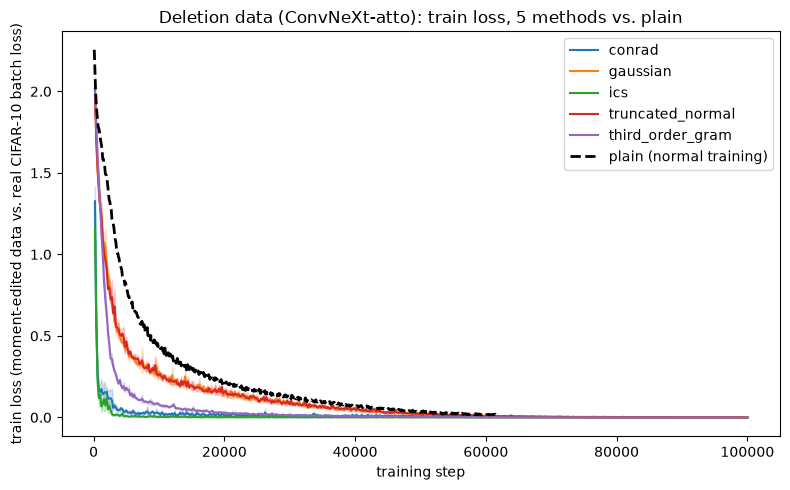

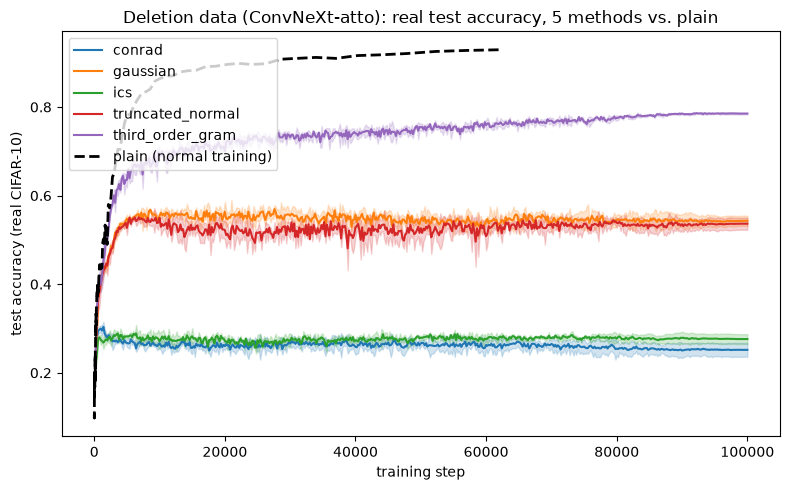

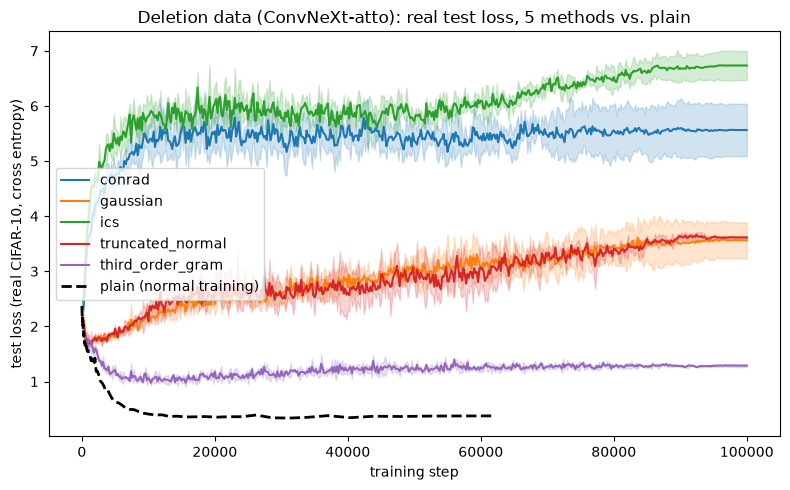

In [2]:
from pathlib import Path

# ── 通常学習 (vision_plain, 編集なしのCIFAR-10で学習) のデータを読み込む ──
PLAIN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10/convnext-atto")

# test_acc, test_loss: 各チェックポイントで実CIFAR-10テストセットを評価したもの
plain_test = pd.read_csv(PLAIN_ROOT / "eval_curve.csv").sort_values("step")

# train_loss: 学習中の(バッチ単位の)cross entropy loss。trainer_state.jsonのlog_historyに
# 100stepごとに記録されている。最終チェックポイント(最大step)のtrainer_state.jsonには
# それまでの全履歴が入っている。
ckpt_steps = sorted(
    int(d.name.split("-")[1]) for d in PLAIN_ROOT.glob("checkpoint-*")
)
final_ckpt = PLAIN_ROOT / f"checkpoint-{ckpt_steps[-1]}"
with open(final_ckpt / "trainer_state.json") as f:
    log_history = json.load(f)["log_history"]
plain_train_loss = pd.DataFrame(
    [{"step": e["step"], "train_loss": e["loss"]} for e in log_history if "loss" in e]
).sort_values("step")

print("plain test curve:", plain_test.shape, " plain train_loss curve:", plain_train_loss.shape)
print("plain step range:", plain_test["step"].min(), "-", plain_test["step"].max())

# 注: vision_plain側は編集データ全体でのtrain_acc(訓練データ全体に対する精度)を
# 学習中に記録していないため、train_accの比較は行えない(train_lossのみ比較可能)。

PLAIN_COLOR = "black"

def plot_metric_with_plain(metric_name, plain_df, ylabel, title, save_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, method in enumerate(METHODS):
        sub = summary[summary["method"] == method].sort_values("step")
        ax.plot(sub["step"], sub[f"{metric_name}_mean"], label=method, color=colors[i])
        ax.fill_between(
            sub["step"],
            sub[f"{metric_name}_mean"] - sub[f"{metric_name}_std"],
            sub[f"{metric_name}_mean"] + sub[f"{metric_name}_std"],
            color=colors[i], alpha=0.2,
        )
    ax.plot(
        plain_df["step"], plain_df[metric_name],
        label="plain (normal training)", color=PLAIN_COLOR,
        linestyle="--", linewidth=2,
    )
    ax.set_xlabel("training step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"/home/nakano/server/llc_results_dense/{save_name}.png", dpi=150)
    plt.show()

plot_metric_with_plain(
    "train_loss", plain_train_loss,
    "train loss (moment-edited data vs. real CIFAR-10 batch loss)",
    "Deletion data (ConvNeXt-atto): train loss, 5 methods vs. plain",
    "deletion_vision_train_loss_gram_vs_plain",
)

plot_metric_with_plain(
    "test_acc", plain_test,
    "test accuracy (real CIFAR-10)",
    "Deletion data (ConvNeXt-atto): real test accuracy, 5 methods vs. plain",
    "deletion_vision_test_acc_gram_vs_plain",
)

plot_metric_with_plain(
    "test_loss", plain_test,
    "test loss (real CIFAR-10, cross entropy)",
    "Deletion data (ConvNeXt-atto): real test loss, 5 methods vs. plain",
    "deletion_vision_test_loss_gram_vs_plain",
)

# モーメント編集データで学習したモデルの最終チェックポイントにおけるLLCの比較